## Example Implementation



In [216]:
import matplotlib.pyplot as plt
import networkx as nx
from graphviz import Digraph
import pandas as pd
import os
import matplotlib

In [278]:
class Module:
    """
    Mock-up class to represent a module in a computational graph.
    This class is used to create a module with a name, input name, and output name.
    """
    def __init__(self, name, inputs=[], outputs=[]):
        self.name = name
        self.inputs = inputs
        self.outputs = outputs
        self.dependencies = {output: [] for output in outputs if output}

    def __repr__(self):
        return f"{self.name}_obj"
    
    def add_dependency(self, output, input):
        """
        Key: output of the module, Value: list of inputs that are used by this output.
        """
        if output not in self.dependencies:
            self.dependencies[output] = []
        self.dependencies[output].append(input)

In [279]:
class CoupledModules:
    """
    Mock-up class to represent a set of coupled modules.
    This class is used to create a set of modules with their names, inputs, and outputs.
    """
    def __init__(self, name, modules, global_connections):
        self.name = name
        self.modules = modules
        self.moule_map = {module.name: module for module in modules}
        
        self.global_connections = global_connections

        self.input_mapping = {}
        self.output_mapping = {}

        self.inputs = {}
        self.outputs = {}

    def __repr__(self):
        return f"{self.name}"


In [280]:
class Simulation:
    """
    Mock-up class to represent a simulation that contains modules.
    This class is used to create a simulation with a list of modules.
    """
    def __init__(self, modules):
        self.modules = modules
        self.module_map = {module.name: module for module in modules}
        self.connections = {}
        self.execution_order = []
        self.coupled_modules = []
        self.module_to_coupled_module = {}
    
    def connect(self, src, output, dst, input=None):
        """
        Assigns the output of a source module as tuple (src, output) 
        to the input key of the destination module's dictionary.
        If input is None, it uses the output name of the source module.
        """
        # Check if the source module exists
        if dst not in self.connections:
            self.connections[dst] = {}
        
        # Get the input name for the destination module
        input_name = input or output

        # Check if the connection already exists
        if input_name in self.connections[dst]:
            existing_src, existing_output = self.connections[dst][input_name]
            raise ValueError(
                f"Input '{input_name}' of module '{dst}' is already connected "
                f"to output '{existing_output}' from module '{existing_src}'."
            )
        
        # Create the connection
        self.connections[dst][input_name] = (src, output)

In [283]:
def build_full_dependency_graph(simulation):
    """
    Build the full dependency graph from the simulation connections.
    """
    full_graph = nx.DiGraph()
    for dest_mod, conn_dict in simulation.connections.items():
        for input_name, (src_mod, output_name) in conn_dict.items():
            full_graph.add_edge(src_mod, dest_mod, input=input_name, output=output_name)
    return full_graph

In [328]:
def build_module_dependency_graph(sim: Simulation) -> nx.DiGraph:
    graph = nx.DiGraph()

    # For each module in the simulation
    for target in sim.modules:
        target_name = target.name

        # Look at each output of the target
        for output, inputs_used in target.dependencies.items():
            for input_name in inputs_used:
                # Get the source module that provides the input to this module
                if target_name not in sim.connections:
                    continue
                if input_name not in sim.connections[target_name]:
                    continue
                source_module_name, _ = sim.connections[target_name][input_name]

                # Add dependency edge from source → target
                if source_module_name != target_name:
                    graph.add_edge(source_module_name, target_name)
    return graph

#### Example 1: Direct Feed-Through

In [337]:
source = Module("Source", outputs=["output_src"])
sink = Module("Sink", inputs=["input_sink"])

moduleA = Module("ModuleA", ["inputA1", "inputA2"], ["outputA1", "outputA2"])
moduleA.add_dependency("outputA1", "inputA2")
moduleA.add_dependency("outputA2", "inputA1")

moduleB = Module("ModuleB", ["inputB1", "inputB2"], ["outputB1", "outputB2"])
moduleB.add_dependency("outputB1", "inputB2")
moduleB.add_dependency("outputB2", "inputB1")

moduleC = Module("ModuleC", ["inputC1", "inputC2"], ["outputC1", "outputC2"])
moduleC.add_dependency("outputC1", "inputC2")
moduleC.add_dependency("outputC2", "inputC1")

sim = Simulation([moduleA, moduleB, moduleC, source, sink])

# Example connections
sim.connect("Source", "output_src", "ModuleA", "inputA1")

sim.connect("ModuleA", "outputA1", "ModuleB", "inputB1")
sim.connect("ModuleA", "outputA2", "moduleB", "inputB2")

sim.connect("ModuleB", "outputB1", "ModuleC", "inputC2")
sim.connect("ModuleB", "outputB2", "ModuleC", "inputC1")

sim.connect("ModuleC", "outputC1", "ModuleA", "inputA2")

sim.connect("ModuleC", "outputC2", "Sink", "input_sink")

# Print for each module within the simulation connections and dependencies
for module in sim.modules:
    print(f"Module: {module.name}")
    print(f"Inputs: {module.inputs}")
    print(f"Outputs: {module.outputs}")
    print(f"Dependencies: {module.dependencies}")
    print()

Module: ModuleA
Inputs: ['inputA1', 'inputA2']
Outputs: ['outputA1', 'outputA2']
Dependencies: {'outputA1': ['inputA2'], 'outputA2': ['inputA1']}

Module: ModuleB
Inputs: ['inputB1', 'inputB2']
Outputs: ['outputB1', 'outputB2']
Dependencies: {'outputB1': ['inputB2'], 'outputB2': ['inputB1']}

Module: ModuleC
Inputs: ['inputC1', 'inputC2']
Outputs: ['outputC1', 'outputC2']
Dependencies: {'outputC1': ['inputC2'], 'outputC2': ['inputC1']}

Module: Source
Inputs: []
Outputs: ['output_src']
Dependencies: {'output_src': []}

Module: Sink
Inputs: ['input_sink']
Outputs: []
Dependencies: {}



In [338]:
graph = build_module_dependency_graph(sim)

In [339]:
# Detect Cycles in the graph
sccs = list(nx.strongly_connected_components(graph))
print("Possible Algebraic Loops (SCCs with > 1 module):")
for scc in sccs:
    if len(scc) > 1:
        print(f" - {scc}")

Possible Algebraic Loops (SCCs with > 1 module):
 - {'ModuleB', 'ModuleC', 'ModuleA'}


In [340]:
sccs

[{'ModuleA', 'ModuleB', 'ModuleC'}, {'Source'}]

In [331]:
# Condense to DAG and topologically sort
condensed = nx.condensation(graph)
execution_order = list(nx.topological_sort(condensed))
print("\nExecution Order (Condensed SCCs):", execution_order)


Execution Order (Condensed SCCs): [1, 0]


In [324]:
# Determines cylclic dependencies
full_graph = build_full_dependency_graph(sim)

# Get the strongly connected components
strongly_connected_components = list(nx.strongly_connected_components(full_graph))

# Print the strongly connected components
print("Components:")
for component in strongly_connected_components:
    if len(component) > 1:
        print(f"Strongly Connected Component: {component}")
    else:
        print(f"Single Node Component:        {component}")

Components:
Single Node Component:        {'Sink'}
Single Node Component:        {'moduleB'}
Strongly Connected Component: {'ModuleB', 'ModuleC', 'ModuleA'}
Single Node Component:        {'Source'}


In [ ]:
sccs = [list(component) for component in strongly_connected_components if len(component) > 1]

# try to find an evaluation order


[['ModuleB', 'ModuleC', 'ModuleA']]

In [220]:
# Create instances of the Module class
moduleA = Module("ModuleA", ["inputA1", "inputA2"], ["outputA1", "outputA2"])
moduleB = Module("ModuleB", ["inputB1", "inputB2"], ["outputB1", "outputB2"])
moduleC = Module("ModuleC", ["inputC1", "inputC2"], ["outputC1", "outputC2"])
moduleD = Module("ModuleD", ["inputD1", "inputD2"], ["outputD1", "outputD2"])
moduleE = Module("ModuleE", ["inputE1", "inputE2"], ["outputE1", "outputE2"])

In [221]:
# Create a simulation instance with the modules
sim = Simulation([moduleA, moduleB, moduleC, moduleD, moduleE])

# Simple connections between modules without feedback loops
sim.connect("ModuleA", "outputA1", "ModuleB", "inputB1")
sim.connect("ModuleB", "outputB1", "ModuleC", "inputC1")
sim.connect("ModuleC", "outputC1", "ModuleD", "inputD1")

# Create a feedback loop
sim.connect("ModuleD", "outputD1", "ModuleE", "inputE1")
sim.connect("ModuleE", "outputE1", "ModuleC", "inputC2")

sim.connections

{'ModuleB': {'inputB1': ('ModuleA', 'outputA1')},
 'ModuleC': {'inputC1': ('ModuleB', 'outputB1'),
  'inputC2': ('ModuleE', 'outputE1')},
 'ModuleD': {'inputD1': ('ModuleC', 'outputC1')},
 'ModuleE': {'inputE1': ('ModuleD', 'outputD1')}}

#### Execution Order

In [223]:
# Step 1: Build the full dependency graph
full_graph = build_full_dependency_graph(sim)

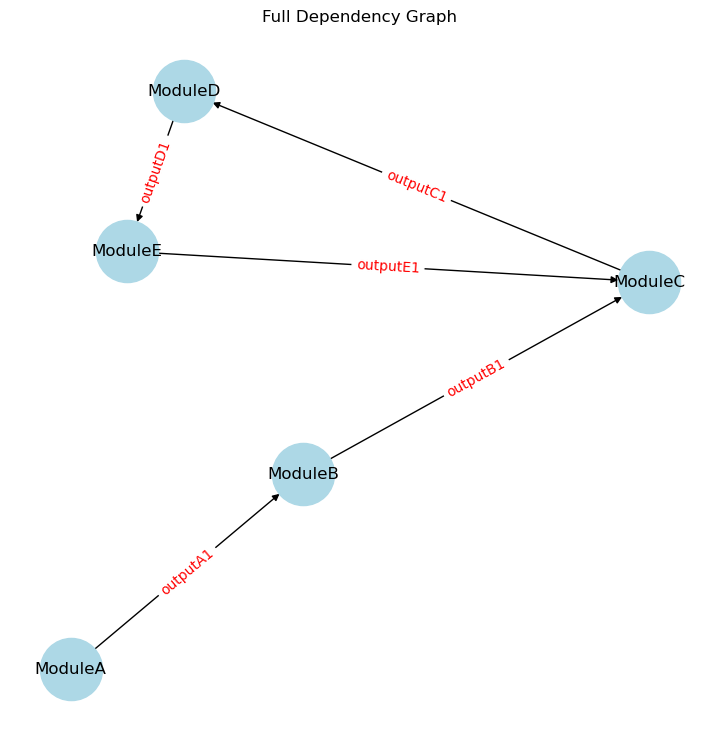

In [224]:
# Show the full dependency graph
plt.figure(figsize=(7, 7))
pos = nx.spring_layout(full_graph)
nx.draw(full_graph, pos,
        with_labels=True,
        arrows=True,
        node_size=2000,
        node_color='lightblue',
        font_size=12,
        font_color='black')
edge_labels = nx.get_edge_attributes(full_graph, 'output')
nx.draw_networkx_edge_labels(full_graph, pos, edge_labels=edge_labels, font_color='red')
plt.title("Full Dependency Graph")
plt.show()

In [225]:
# Step 2: Detect strongly connected components
strongly_connected_components = list(nx.strongly_connected_components(full_graph))
print("Strongly Connected Components:")
for i, scc in enumerate(strongly_connected_components):
    print(f"SCC {i + 1}: {scc}")

Strongly Connected Components:
SCC 1: {'ModuleE', 'ModuleD', 'ModuleC'}
SCC 2: {'ModuleB'}
SCC 3: {'ModuleA'}


In [226]:
# Step 3: Extract internal order for each strongly connected component
ordered_sccs = []
for scc in strongly_connected_components:
    scc = list(scc)
    if len(scc) == 1:
        ordered_sccs.append(scc)
    else:
        # Create a subgraph for the strongly connected component
        subgraph = full_graph.subgraph(scc).copy()

        # Apply DFS post-ordering
        order = list(nx.dfs_postorder_nodes(subgraph))

        # Reverse the order to get the execution order
        order = list(reversed(order))
        ordered_sccs.append(order)

# Display the ordered strongly connected components
print("\nOrdered Strongly Connected Components:")
for i, order in enumerate(ordered_sccs):
    print(f"Ordered SCC {i + 1}: {order}")


Ordered Strongly Connected Components:
Ordered SCC 1: ['ModuleC', 'ModuleD', 'ModuleE']
Ordered SCC 2: ['ModuleB']
Ordered SCC 3: ['ModuleA']


In [227]:
# Step 4: Instantiate CoupledModules and prepare group mapping
num_coupled_modules = 0
for scc in ordered_sccs:
    if len(scc) > 1:
        num_coupled_modules += 1
        # Create a CoupledModules instance for the strongly connected component
        modules = [sim.module_map[name] for name in scc]
        coupled_module = CoupledModules(f"CM_{num_coupled_modules}",
                                        modules,
                                        sim.connections)
        sim.coupled_modules.append(coupled_module)

        # Map each module to its coupled module
        for module in modules:
            sim.module_to_coupled_module[module.name] = coupled_module
        
        # Add the coupled module to the simulation's execution order
        sim.execution_order.append(coupled_module)

In [ ]:
# Step 5: Build the reduced dependency graph between coupled modules and standalone modules
reduced_graph = nx.DiGraph()
for dest_mod, conn_dict in sim.connections.items():
    # Return the coupled module if the destination module is part of a coupled module
    dest_coupled_module = sim.module_to_coupled_module.get(dest_mod, dest_mod)
    
    for dest_input_name, (src_mod, output_name) in conn_dict.items():
        # Return the coupled module if the source module is part of a coupled module
        src_coupled_module = sim.module_to_coupled_module.get(src_mod, src_mod)
        
        if src_coupled_module != dest_coupled_module:
            # If the source and destination are different, add an edge in the reduced graph
            reduced_graph.add_edge(src_coupled_module, dest_coupled_module)

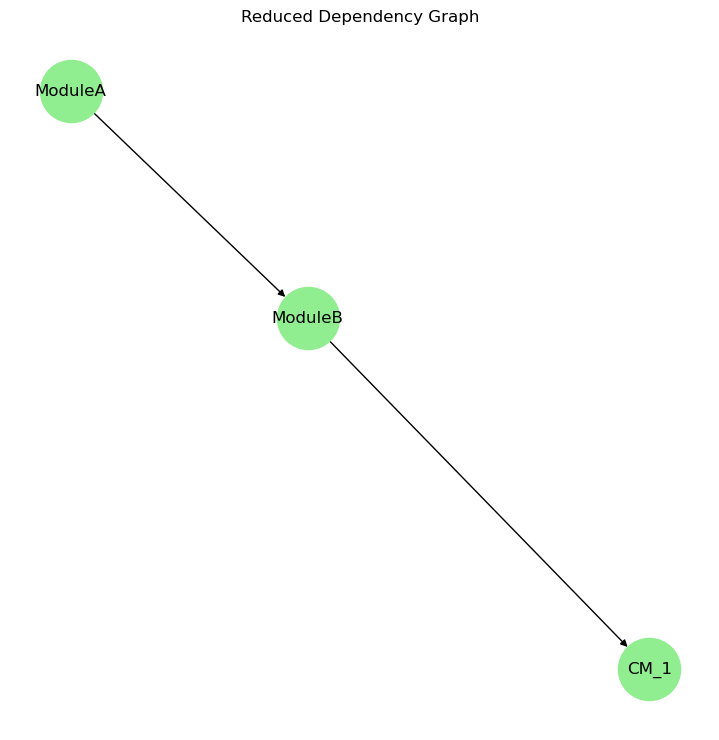

In [229]:
# Plot the reduced dependency graph
plt.figure(figsize=(7, 7))
pos = nx.spring_layout(reduced_graph)
nx.draw(reduced_graph, pos,
        with_labels=True,
        arrows=True,
        node_size=2000,
        node_color='lightgreen',
        font_size=12,
        font_color='black')
edge_labels = nx.get_edge_attributes(reduced_graph, 'output')   
nx.draw_networkx_edge_labels(reduced_graph, pos, edge_labels=edge_labels, font_color='red')
plt.title("Reduced Dependency Graph")
plt.show()

In [ ]:
# Sanity check: Ensure that the execution order is correct
if not nx.is_directed_acyclic_graph(reduced_graph):
    raise RuntimeError("Cycle detected between CoupledBlocks or modules — execution order is invalid.")

In [247]:
# Step 6: Peform topological sorting on the reduced graph to get the execution order
name_to_object = {mod.name: mod for mod in sim.modules}

# Update the dictionary to include coupled modules
name_to_object.update({cm.name: cm for cm in sim.coupled_modules})

# Perform topological sorting to get the sorted order
sim.execution_order = list(nx.topological_sort(reduced_graph))

# Display the execution order
print("\nExecution Order:")
print(sim.execution_order)



Execution Order:
['ModuleA', 'ModuleB', CM_1]


In [ ]:


# Display the execution order
print("\nExecution Order:")
for i, module in enumerate(sim.execution_order):
    if isinstance(module, CoupledModules):
        print(f"{i + 1}. Coupled Module: {module.name}")
    else:
        print(f"{i + 1}. Module: {module.name}")

KeyError: CM_1

### Assign Execulation Levels for Standalone Modules and Sublevels for CoupledModules

In [ ]:
def increment_sublevel(current):
    """Helper to generate sublevels like 3.1 → 3.9 → 3.91
        → 3.99 → 3.991 ..."""
    # Convert the current value
    str_val = str(current)

    # If there is no decimal point, increment by 0.1
    if '.' not in str_val:
        return current + 0.1
    
    # Split the string into prefix and suffix
    prefix, suffix = str_val.split('.')
    start = suffix[:-1]
    last_digit = suffix[-1]

    # Check if the last digit is '9'
    if last_digit == "9":
        last_digit = "91"
    # If the last digit is not '9', increment it by 1
    else:
        last_digit = int(last_digit) + 1
    
    # Create the new sublevel
    sublevel = float(f"{prefix}.{start}{last_digit}")
    return sublevel

In [ ]:
# Stage 1: Assign top-level levels